<a href="https://colab.research.google.com/github/Apichaya-bu/229352-stat-learning-for-data2/blob/main/%E0%B8%AA%E0%B8%B3%E0%B9%80%E0%B8%99%E0%B8%B2%E0%B8%82%E0%B8%AD%E0%B8%87_Lab06_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #6

## Support Vector Machines (SVM)

[SVM module documentation](https://scikit-learn.org/stable/modules/svm.html#svm)

[LinearSVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

[SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC  # fast but only linear
from sklearn.svm import SVC  # slower but can do kernels

In [2]:
# Load the iris data
iris = datasets.load_iris()
X = iris.data[:, 2:]
y = iris.target

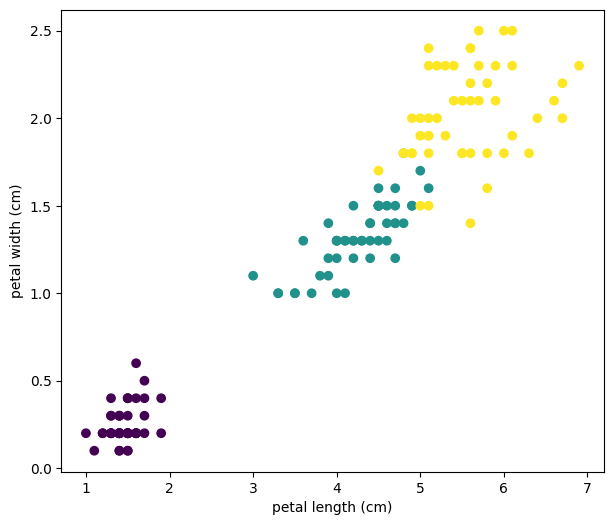

In [3]:
# Plot the data
plt.figure(figsize=(7,6))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.show()

#### In this problem, you'll use support vector machines to classify the Iris data

#### The following function helps you plot the decision boundary.

In [4]:
# Plot the decision boundaries
def plot_decision_boundary(clf, X, y):
    h = 0.005  # Boundary lines' resolution
    x_min, x_max = X[:,0].min() - 10*h, X[:,0].max() + 10*h
    y_min, y_max = X[:,1].min() - 10*h, X[:,1].max() + 10*h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, alpha=0.25)  # Background
    plt.contour(xx, yy, Z, colors='k', linewidths=0.2)  # Boundary lines
    plt.scatter(X[:,0], X[:,1], c=y);  # Data points
    plt.xlabel(iris.feature_names[2])
    plt.ylabel(iris.feature_names[3])

#### Exercise 1. Split the data into training set and test set.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Exercise 2. Learn a linear SVM classifier using sklearn.svm.LinearSVC. You will need to set `loss='hinge'`.

#### Try different values of the tradeoff parameter: `C = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `C` on the decision boundary?

Training LinearSVC with C=0.01


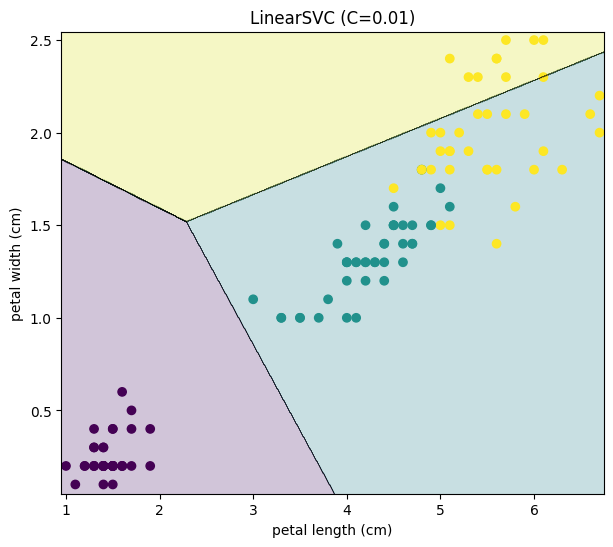

Training LinearSVC with C=0.1


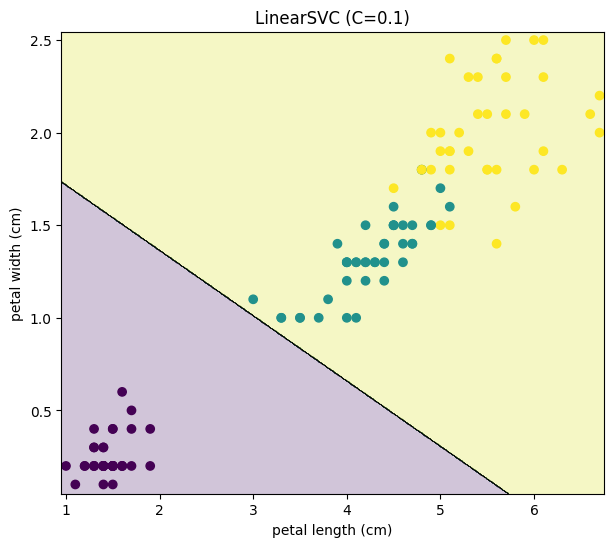

Training LinearSVC with C=1.0


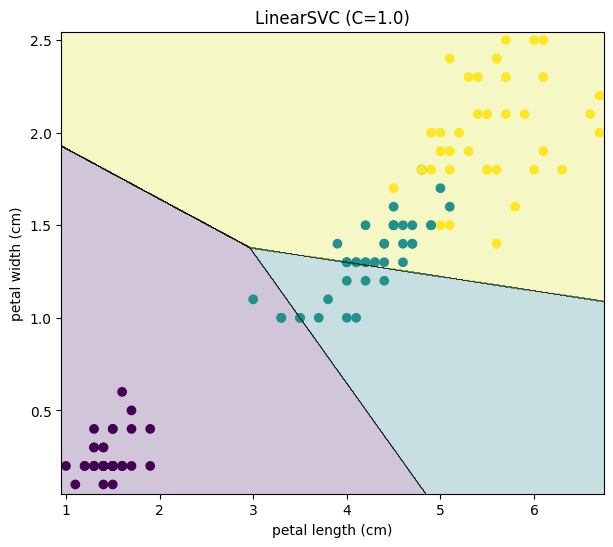

Training LinearSVC with C=10.0


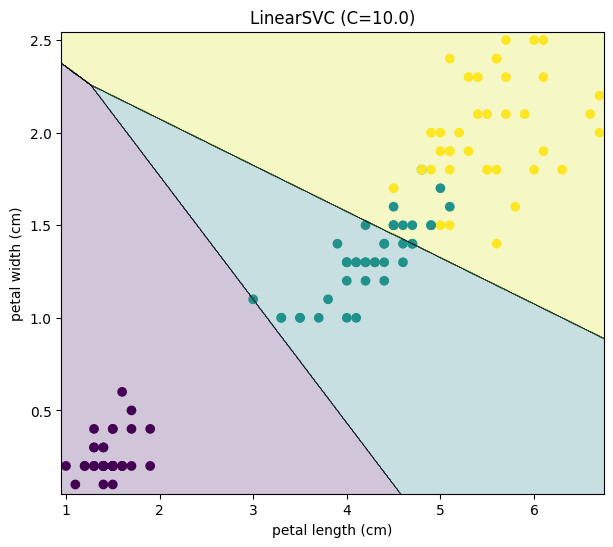

Training LinearSVC with C=100.0


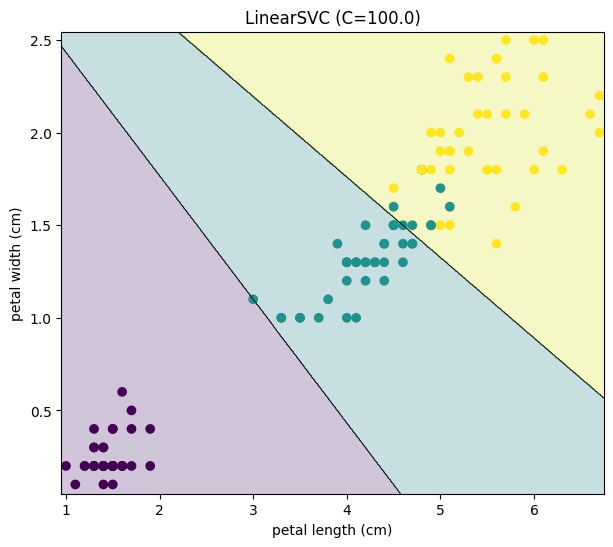

In [6]:
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

for c_val in C_values:
    print(f"Training LinearSVC with C={c_val}")

    lin_svm = LinearSVC(loss='hinge', C=c_val, max_iter=100000)
    lin_svm.fit(X_train, y_train)

    plot_decision_boundary(lin_svm, X_train, y_train)
    plt.title(f"LinearSVC (C={c_val})")
    plt.show()


#### Exercise 3. Pick a value of `C` that you like. Then report the test error.

In [7]:
chosen_c = 1.0
final_lin_svm = LinearSVC(loss='hinge', C=chosen_c, max_iter=100000)
final_lin_svm.fit(X_train, y_train)

test_score = final_lin_svm.score(X_test, y_test)
test_error = 1 - test_score

print(f"Test Accuracy: {test_score:.4f}")
print(f"Test Error: {test_error:.4f}")


Test Accuracy: 0.8333
Test Error: 0.1667


#### Exercise 4. Now try kernel SVM with a quadratic kernel. You can do this with sklearn.svm.SVC, setting `kernel='rbf'` and `C = 1.0`.

#### Try different values of the tradeoff parameter: `gamma = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `gamma` on the decision boundary?

Training Kernel SVM with gamma=0.01


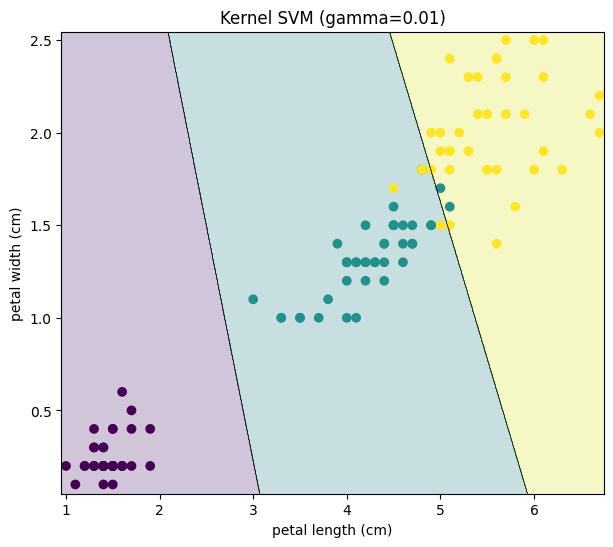

Training Kernel SVM with gamma=0.1


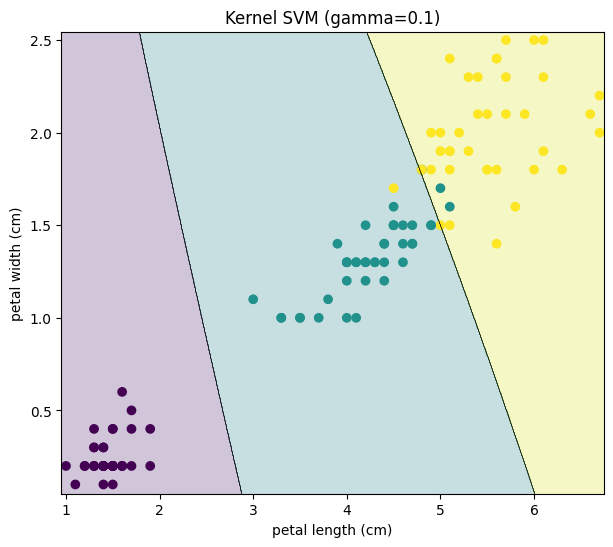

Training Kernel SVM with gamma=1.0


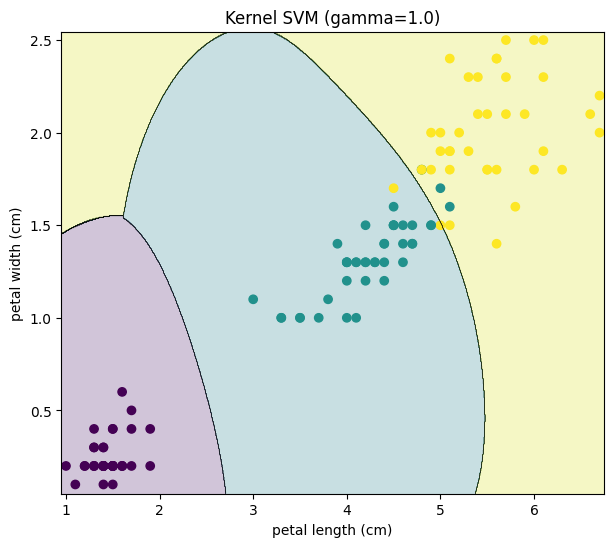

Training Kernel SVM with gamma=10.0


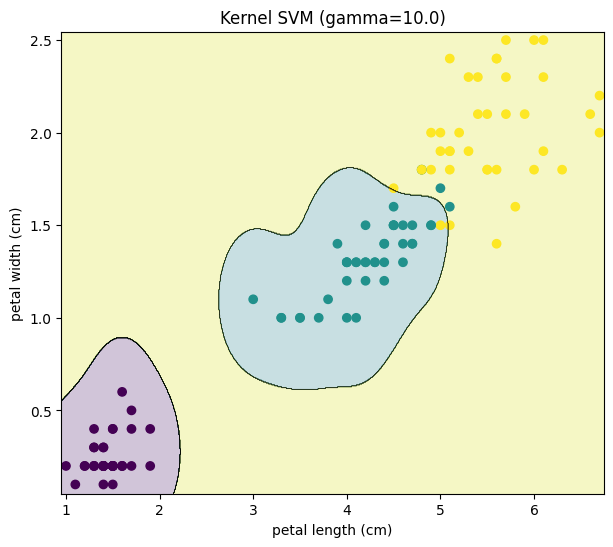

Training Kernel SVM with gamma=100.0


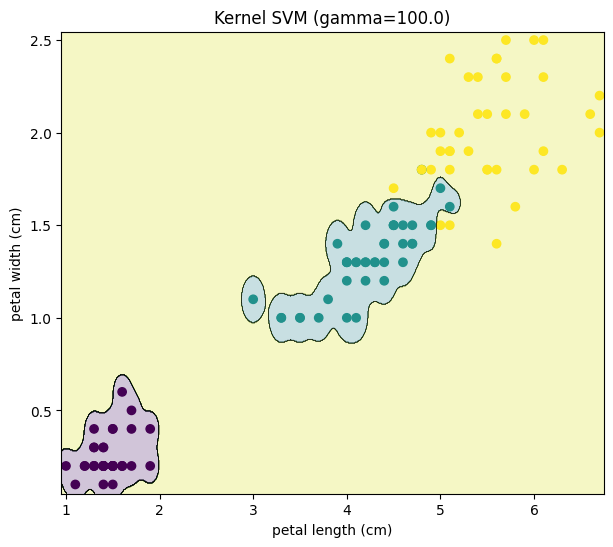

In [8]:
gamma_values = [0.01, 0.1, 1.0, 10.0, 100.0]

for g_val in gamma_values:
    print(f"Training Kernel SVM with gamma={g_val}")
    rbf_svm = SVC(kernel='rbf', C=1.0, gamma=g_val, max_iter=100000)
    rbf_svm.fit(X_train, y_train)

    plot_decision_boundary(rbf_svm, X_train, y_train)
    plt.title(f"Kernel SVM (gamma={g_val})")
    plt.show()


#### Exercise 5. Pick a value of `gamma` that you like. Then report the test error and the number of support vectors.

In [9]:
chosen_gamma = 1.0
final_rbf_svm = SVC(kernel='rbf', C=1.0, gamma=chosen_gamma)
final_rbf_svm.fit(X_train, y_train)

test_error_rbf = 1 - final_rbf_svm.score(X_test, y_test)
n_support_vectors = final_rbf_svm.support_vectors_.shape[0]

print(f"Test Error: {test_error_rbf:.4f}")
print(f"Number of Support Vectors: {n_support_vectors}")


Test Error: 0.0000
Number of Support Vectors: 30


#### Exercise 6. Between Linear SVM and Kernel SVM, which model would you prefer to use for classification of Iris data?
1. Explain using test accuracy
2. Explaing using decision boundary plot

1. Explain using test accuracy: โดยปกติ Kernel SVM (RBF) มักจะได้ Accuracy ที่สูงกว่าหรือเท่ากับ Linear SVM เพราะมีความยืดหยุ่นในการสร้างเส้นแบ่งที่ซับซ้อนกว่า (Non-linear)
2. Explain using decision boundary plot: จากรูปจะเห็นว่า Linear SVM สร้างได้แค่เส้นตรง ซึ่งอาจจะแยกกลุ่มข้อมูลที่ซ้อนทับกันได้ไม่ดีเท่า Kernel SVM ที่สร้างเส้นโค้งล้อมรอบกลุ่มข้อมูลได้แม่นยำกว่า